# FounderAI Colab Train + Eval V2

Notebook dedie au retrain sur Colab avec evaluation du training:
- train loss
- validation loss
- test loss
- perplexity
- signaux d'overfit
- courbe de loss

Usage:
1. Runtime > Change runtime type
2. Choisis `T4 GPU` si disponible
3. Clique `Run all`


In [1]:
import subprocess
from pathlib import Path

RUN_ROOT = Path('/content/founderai-colab-train-eval')
REPO_URL = 'https://github.com/leyeleye22/FounderAI.git'

if not RUN_ROOT.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(RUN_ROOT)], check=True)
else:
    print('Repo already present at', RUN_ROOT)

OUTPUT_DIR = RUN_ROOT / 'colab_outputs' / 'lora_adapter'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', RUN_ROOT)
print('Output dir:', OUTPUT_DIR)


Repo root: /content/founderai-colab-train-eval
Output dir: /content/founderai-colab-train-eval/colab_outputs/lora_adapter


In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print('Set safer CUDA allocation mode for Colab GPUs.')


Set safer CUDA allocation mode for Colab GPUs.


In [3]:
!pip install -q transformers>=4.51.0 peft>=0.10.0 accelerate>=0.28.0 bitsandbytes>=0.43.0 datasets>=2.18.0 trl>=0.8.0 torch>=2.2.0 sentencepiece>=0.2.0 protobuf>=4.25.0 matplotlib>=3.8.0


In [4]:
!nvidia-smi


Tue May  5 16:42:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os

os.environ['FOUNDER_AI_COLAB_BASE_MODEL'] = 'Qwen/Qwen3-4B'
os.environ['FOUNDER_AI_COLAB_DATA_PATH'] = str(RUN_ROOT / 'training_data' / 'teranga_merged.jsonl')
os.environ['FOUNDER_AI_COLAB_OUTPUT_DIR'] = str(OUTPUT_DIR)
os.environ['FOUNDER_AI_COLAB_METRICS_PATH'] = str(OUTPUT_DIR / 'training_metrics.json')
os.environ['FOUNDER_AI_COLAB_HISTORY_PATH'] = str(OUTPUT_DIR / 'training_history.json')
os.environ['FOUNDER_AI_COLAB_REPORT_PATH'] = str(OUTPUT_DIR / 'training_report.md')
os.environ['FOUNDER_AI_COLAB_PLOT_PATH'] = str(OUTPUT_DIR / 'loss_curve.png')
os.environ['FOUNDER_AI_COLAB_USE_4BIT'] = 'true'
os.environ['FOUNDER_AI_COLAB_EPOCHS'] = '1'
os.environ['FOUNDER_AI_COLAB_MAX_SEQ_LENGTH'] = '512'
os.environ['FOUNDER_AI_COLAB_GRAD_ACCUM'] = '8'
os.environ['FOUNDER_AI_COLAB_SAVE_STEPS'] = '25'
os.environ['FOUNDER_AI_COLAB_EVAL_STEPS'] = '25'
os.environ['FOUNDER_AI_COLAB_SAMPLE_LIMIT'] = '120'
print('Training config ready.')
print('Sample limit:', os.environ['FOUNDER_AI_COLAB_SAMPLE_LIMIT'])


Training config ready.
Sample limit: 120


In [6]:
import subprocess
from pathlib import Path

log_path = OUTPUT_DIR / 'training_run.log'
script_path = RUN_ROOT / 'training_data' / 'train_qwen3_lora_colab.py'

with log_path.open('w', encoding='utf-8') as log_file:
    result = subprocess.run(
        ['python', str(script_path)],
        cwd=str(RUN_ROOT),
        stdout=log_file,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

log_text = log_path.read_text(encoding='utf-8')
print(log_text[:12000])
if result.returncode != 0:
    print('\n--- LOG TAIL ---\n')
    print(log_text[-12000:])
    raise RuntimeError(f'Training failed with exit code {result.returncode}. Full log saved at {log_path}')


{
  "gpu": {
    "cuda": true,
    "name": "Tesla T4",
    "total_memory_gb": 14.56,
    "bf16_supported": true,
    "compute_capability": "7.5",
    "preferred_dtype": "float16"
  },
  "config": {
    "base_model_id": "Qwen/Qwen3-4B",
    "data_path": "/content/founderai-colab-train-eval/training_data/teranga_merged.jsonl",
    "output_dir": "/content/founderai-colab-train-eval/colab_outputs/lora_adapter",
    "metrics_path": "/content/founderai-colab-train-eval/colab_outputs/lora_adapter/training_metrics.json",
    "history_path": "/content/founderai-colab-train-eval/colab_outputs/lora_adapter/training_history.json",
    "report_path": "/content/founderai-colab-train-eval/colab_outputs/lora_adapter/training_report.md",
    "plot_path": "/content/founderai-colab-train-eval/colab_outputs/lora_adapter/loss_curve.png",
    "sample_limit": 120,
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "lora_target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
    

In [7]:
import json
from pathlib import Path

metrics_path = OUTPUT_DIR / 'training_metrics.json'
report_path = OUTPUT_DIR / 'training_report.md'
history_path = OUTPUT_DIR / 'training_history.json'

if not metrics_path.exists():
    raise FileNotFoundError(f'Missing metrics file at {metrics_path}')

metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
summary = {
    'train_loss': metrics.get('train_loss'),
    'validation_loss': metrics.get('validation_loss'),
    'test_loss': metrics.get('test_loss'),
    'validation_perplexity': metrics.get('validation_perplexity'),
    'test_perplexity': metrics.get('test_perplexity'),
    'overfit_analysis': metrics.get('overfit_analysis'),
    'best_model_checkpoint': metrics.get('best_model_checkpoint'),
}
print(json.dumps(summary, ensure_ascii=False, indent=2))
print('History file exists:', history_path.exists())
print('Report file exists:', report_path.exists())


{
  "train_loss": 3.5057511647542317,
  "validation_loss": 3.1583237648010254,
  "test_loss": 3.0309300422668457,
  "validation_perplexity": 23.53111916192769,
  "test_perplexity": 20.71649084461188,
  "overfit_analysis": {
    "risk_level": "low",
    "best_validation_loss": null,
    "best_validation_step": null,
    "final_validation_loss": 3.1583237648010254,
    "train_loss": 3.5057511647542317,
    "validation_loss": 3.1583237648010254,
    "test_loss": 3.0309300422668457,
    "reasons": [
      "no strong overfitting signal detected from the available loss curves"
    ],
    "train_points": 3,
    "eval_points": 0
  },
  "best_model_checkpoint": null
}
History file exists: True
Report file exists: True


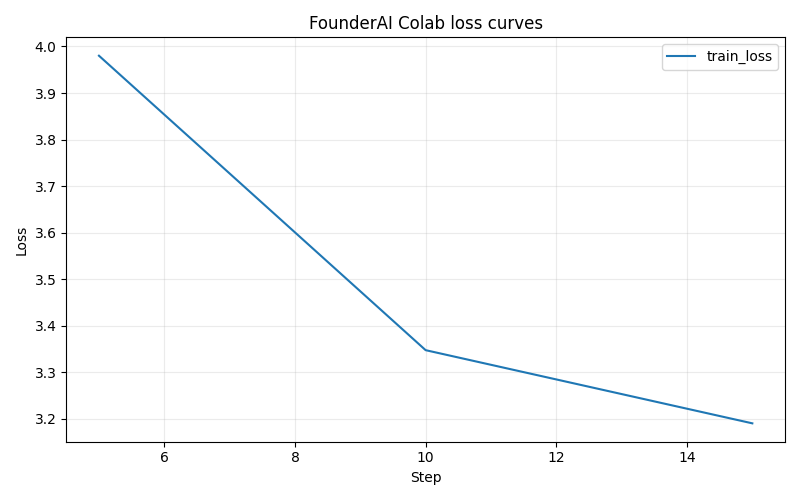

# FounderAI Colab Training Report

## Summary

- Base model: `Qwen/Qwen3-4B`
- Train loss: `3.5057511647542317`
- Validation loss: `3.1583237648010254`
- Test loss: `3.0309300422668457`
- Validation perplexity: `23.53111916192769`
- Test perplexity: `20.71649084461188`
- Overfit risk: `low`

## Overfit analysis

- no strong overfitting signal detected from the available loss curves

## Curve checkpoints

- Best validation loss: `None`
- Best validation step: `None`
- Final validation loss: `3.1583237648010254`
- Logged train points: `3`
- Logged eval points: `0`

In [8]:
from IPython.display import Image, Markdown, display

plot_path = OUTPUT_DIR / 'loss_curve.png'
report_path = OUTPUT_DIR / 'training_report.md'

if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print('No loss curve found.')

if report_path.exists():
    display(Markdown(report_path.read_text(encoding='utf-8')))
else:
    print('No markdown report found.')


In [9]:
import shutil
from google.colab import files

archive_path = shutil.make_archive(str(OUTPUT_DIR.parent / 'founderai_lora_adapter_train_eval_v2'), 'zip', str(OUTPUT_DIR))
print('Created archive:', archive_path)
files.download(archive_path)


Created archive: /content/founderai-colab-train-eval/colab_outputs/founderai_lora_adapter_train_eval_v2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>